Assignment 13 Name: Shlok Nikam PRN: 12414145 Batch: 2 Division: D Branch: CSE(AI)

11. Assignment on Classification technique. Every year many students give the GRE exam to get admission in foreign Universities. The data set contains GRE Scores (out of 340), TOEFL Scores (out of 120), University Rating (out of 5), Statement of Purpose strength (out of 5), Letter of Recommendation strength (out of 5), Undergraduate GPA (out of 10), Research Experience (0=no, 1=yes), Admitted (0=no, 1=yes). Admitted is the target variable.

Data Set: https://www.kaggle.com/mohansacharya/graduate-admissions

The counsellor of the firm is supposed check whether the student will get an admission or not based on his/her GRE score and Academic Score. So to help the counsellor to make appropriate decisions, build a machine learning model classifier using a Decision tree to predict whether a student will get admission or not.  Apply Data pre-processing (Label Encoding, Data Transformation….) techniques if necessary.

Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.



## Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2: Load Dataset

In [ ]:
df = pd.read_csv('Admission_Predict.csv')
print('Shape:', df.shape)
df.head()

Shape: (400, 9)


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


## Step 3: Data Exploration

In [ ]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [ ]:
print('Statistical Summary:')
df.describe()

Statistical Summary:


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [ ]:
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


## Step 4: Data Pre-Processing

In [ ]:
# Drop Serial No. (not a feature)
df.drop(columns=['Serial No.'], inplace=True)

# Rename columns for clarity
df.columns = ['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance_of_Admit']

# Create binary target: Admitted = 1 if Chance_of_Admit >= 0.6, else 0
df['Admitted'] = (df['Chance_of_Admit'] >= 0.6).astype(int)

print('Target variable distribution:')
print(df['Admitted'].value_counts())
print(f'\n0 = Not Admitted, 1 = Admitted')
df.head()

Target variable distribution:
Admitted
1    327
0     73
Name: count, dtype: int64

0 = Not Admitted, 1 = Admitted


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit,Admitted
0,337,118,4,4.5,4.5,9.65,1,0.92,1
1,324,107,4,4.0,4.5,8.87,1,0.76,1
2,316,104,3,3.0,3.5,8.00,1,0.72,1
3,322,110,3,3.5,2.5,8.67,1,0.80,1
4,314,103,2,2.0,3.0,8.21,0,0.65,1


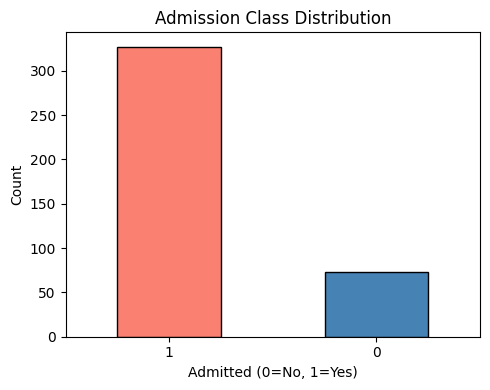

In [ ]:
# Visualize class distribution
plt.figure(figsize=(5, 4))
df['Admitted'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black')
plt.title('Admission Class Distribution')
plt.xlabel('Admitted (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 5: Feature Selection & Data Transformation
- `Chance_of_Admit` is dropped as it was used to derive the target.
- `Research` is already binary encoded (0/1).
- No additional Label Encoding needed as all features are numeric.

In [ ]:
# Drop Chance_of_Admit (source of target, not a real feature at prediction time)
X = df.drop(columns=['Chance_of_Admit', 'Admitted'])
y = df['Admitted']

print('Feature columns:', list(X.columns))
print('Target column: Admitted')
print('Feature matrix shape:', X.shape)

Feature columns: ['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research']
Target column: Admitted
Feature matrix shape: (400, 7)


## Step 6: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set size : {X_train.shape[0]} samples')
print(f'Testing  set size : {X_test.shape[0]} samples')

Training set size : 320 samples
Testing  set size : 80 samples


## Step 7: Apply Decision Tree Classifier

In [ ]:
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
print('Decision Tree model trained successfully!')

Decision Tree model trained successfully!


## Step 8: Model Evaluation

In [ ]:
y_pred = dt_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc * 100:.2f}%\n')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Admitted', 'Admitted']))

Accuracy: 85.00%

Classification Report:
              precision    recall  f1-score   support

Not Admitted       0.78      0.41      0.54        17
    Admitted       0.86      0.97      0.91        63

    accuracy                           0.85        80
   macro avg       0.82      0.69      0.72        80
weighted avg       0.84      0.85      0.83        80



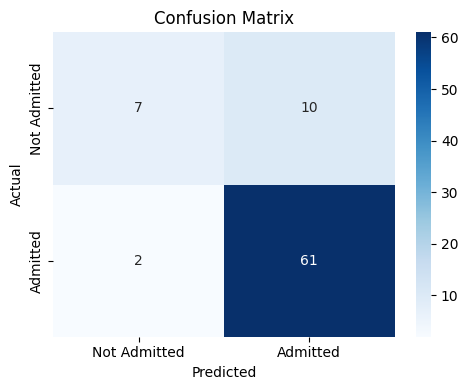

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Admitted', 'Admitted'],
            yticklabels=['Not Admitted', 'Admitted'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

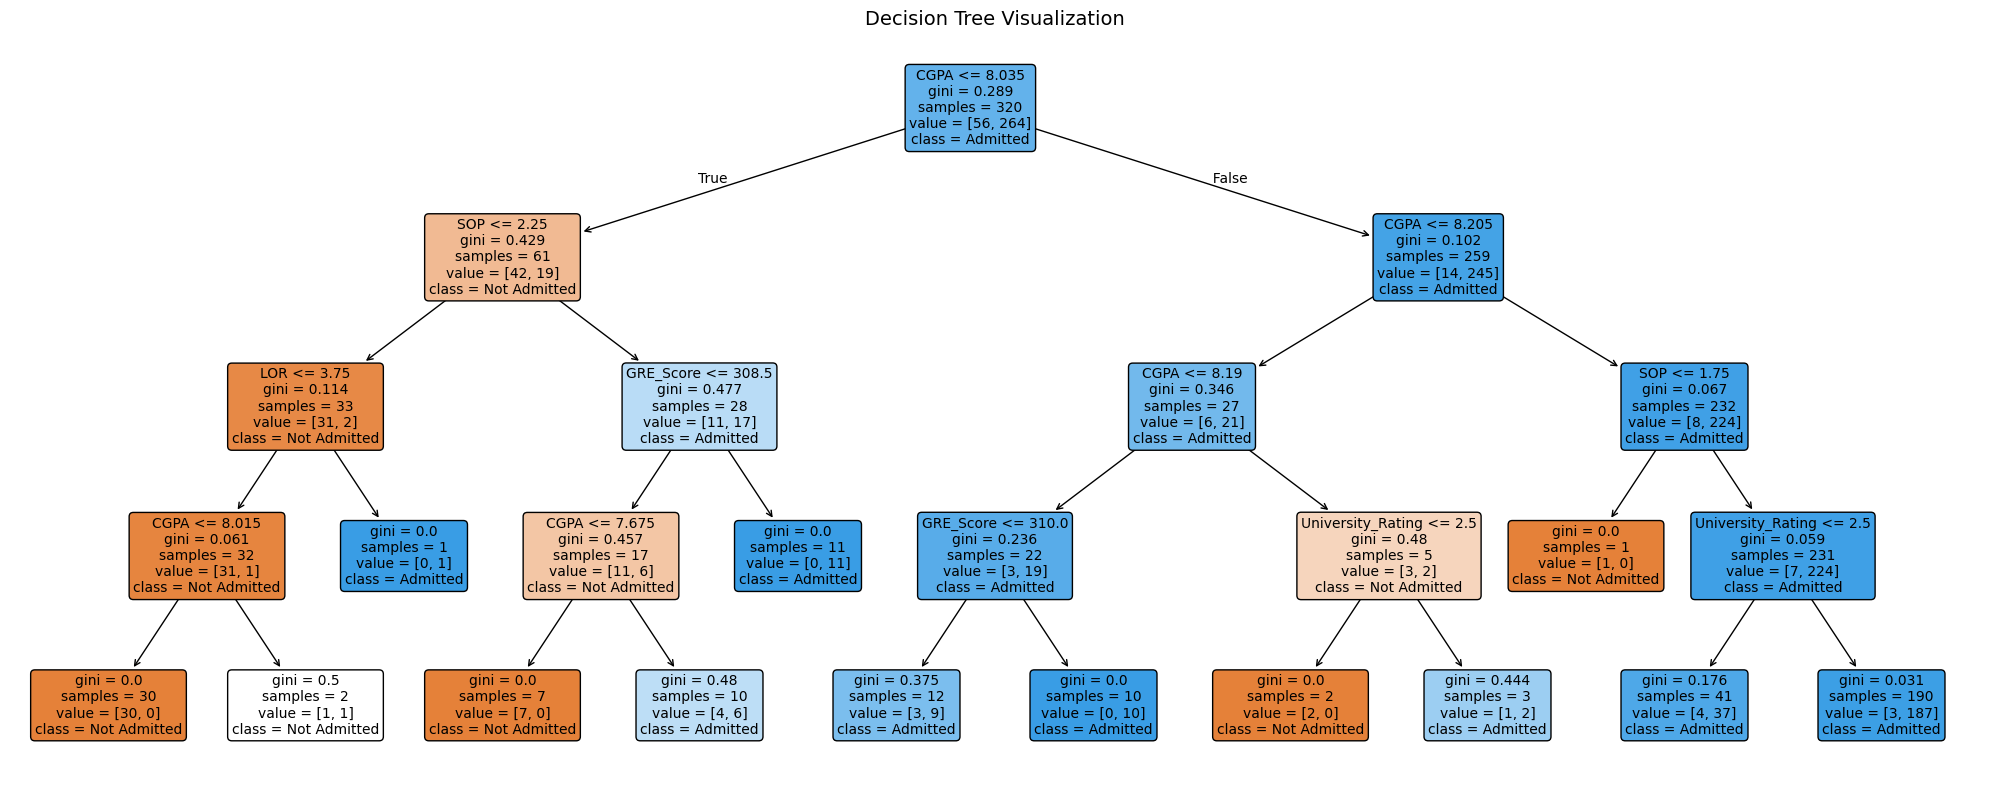

In [ ]:
# Decision Tree Visualization
plt.figure(figsize=(20, 8))
plot_tree(dt_model, feature_names=X.columns, class_names=['Not Admitted', 'Admitted'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Visualization', fontsize=14)
plt.tight_layout()
plt.show()

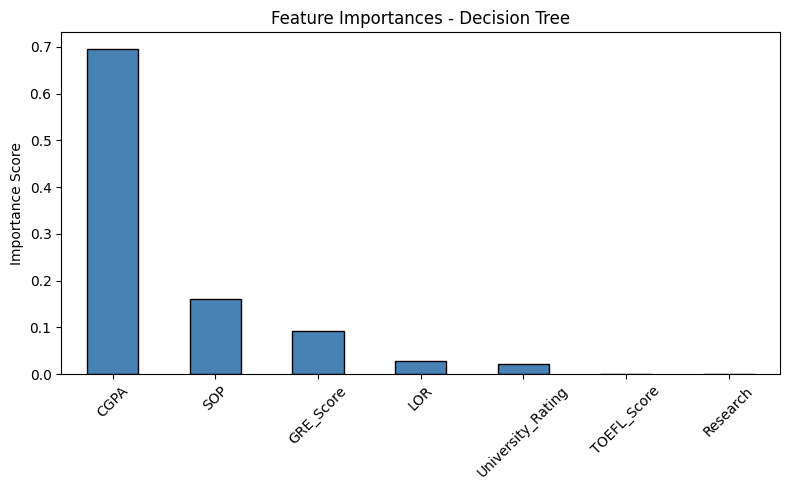

CGPA                 0.696435
SOP                  0.161464
GRE_Score            0.092757
LOR                  0.026908
University_Rating    0.022437
TOEFL_Score          0.000000
Research             0.000000
dtype: float64


In [ ]:
# Feature Importance
importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importances - Decision Tree')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(importances)

## Step 9: Predict for a New Student (Counsellor Use)
The counsellor can input a student's scores to predict admission.

In [ ]:
# Example: New student data
new_student = pd.DataFrame([{
    'GRE_Score': 320,
    'TOEFL_Score': 110,
    'University_Rating': 3,
    'SOP': 3.5,
    'LOR': 3.5,
    'CGPA': 8.5,
    'Research': 1
}])

prediction = dt_model.predict(new_student)[0]
result = 'Admitted ✅' if prediction == 1 else 'Not Admitted ❌'
print(f'Prediction for the new student: {result}')

Prediction for the new student: Admitted ✅
